# K=8 Probabilistic Archetypal Autoencoder — Full Dataset Analysis

Comprehensive deconvolution analysis of the breast CyTOF dataset using the K=8 PAE  
model trained on the full dataset (seed 42, 100 epochs early-stopped).

**Dataset:** 1,131,788 cells × 31 markers across 15 samples  
**Model run:** `outputs/breast_pae_k_sweep/runs/probabilistic_archetypal_ae/dim_08/seed_42/`

**Sections:**
1. Setup & data loading
2. Training history
3. Archetype latent-dimension loadings (component means)
4. Archetype uncertainty profiles (component variances)
5. Top marker loadings per archetype
6. Cell deconvolution overview: entropy and weight distributions
7. Per-sample deconvolution
8. UMAP of cell weights
9. Marker ↔ archetype correlations
10. Reconstruction quality

In [67]:
from __future__ import annotations

import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import seaborn as sns
from pathlib import Path
from scipy import stats
import anndata as ad
import umap

# ── Paths ─────────────────────────────────────────────────────────────────────
BASE        = Path('/Users/ronguy/Dropbox/Work/CyTOF/Experiments/ProbAE_Deconv')
RUN_DIR     = BASE / 'outputs/breast_pae_k5/runs/probabilistic_archetypal_ae/dim_05/seed_42'
DATA_H5AD   = BASE / 'data/breast_cytof_processed.h5ad'
OUT_DIR     = BASE / 'outputs/breast_pae_k5_analysis'
OUT_DIR.mkdir(parents=True, exist_ok=True)

# ── Style ─────────────────────────────────────────────────────────────────────
sns.set_theme(style='ticks', context='notebook', font_scale=1.05)
COMP_COLORS  = sns.color_palette('tab10', 5)   # one colour per archetype
COMP_NAMES   = [
    'A0: Immune/non-epithelial',
    'A1: Luminal B',
    'A2: Luminal A (mature)',
    'A3: Cycling (G2/S)',
    'A4: Basal-like/CAF',
]
N_ARCHETYPES = 5
WEIGHT_COLS  = [f'w_{i}' for i in range(N_ARCHETYPES)]

print('Paths OK. Output →', OUT_DIR)

Paths OK. Output → /Users/ronguy/Dropbox/Work/CyTOF/Experiments/ProbAE_Deconv/outputs/breast_pae_k05_analysis


In [68]:
adata = ad.read_h5ad(DATA_H5AD)

---
## 1  Data loading

In [69]:
# ── Archetype parameters ───────────────────────────────────────────────────────
means_df = pd.read_csv(RUN_DIR / 'component_means.csv', index_col=0)
vars_df  = pd.read_csv(RUN_DIR / 'component_vars.csv',  index_col=0)
hist_df  = pd.read_csv(RUN_DIR / 'training_history.csv')

means_df.index = COMP_NAMES
vars_df.index  = COMP_NAMES
MARKERS = list(means_df.columns)

print(f'Archetype means  : {means_df.shape}  (archetypes × markers)')
print(f'Archetype vars   : {vars_df.shape}')
print(f'Training history : {len(hist_df)} epochs')
print(f'Markers ({len(MARKERS)}): {MARKERS}')

Archetype means  : (5, 31)  (archetypes × markers)
Archetype vars   : (5, 31)
Training history : 494 epochs
Markers (31): ['aSMA', 'BMI-1', 'CD24', 'CD44', 'CD49f', 'ECad', 'EpCam', 'ER', 'EZH2', 'GATA3', 'gH2AX', 'H2Aub', 'H3K27ac', 'H3K27me2', 'H3K27me3', 'H3K36me2', 'H3K36me3', 'H3K4me1', 'H3K4me3', 'H3K64ac', 'H3K9ac', 'H3K9me2', 'H3K9me3', 'H3S28p', 'H4K16ac', 'H4K20me3', 'K5', 'K8-18', 'Ki67', 'panKeratin', 'Vimentin']


In [70]:
# ── Load all cell weights (train + val + test) ─────────────────────────────────
# NOTE: train/ uses internal IDs ('train_0', …), val/ and test/ use original cell IDs.
# We tag each split and combine for aggregate analyses.

def load_weights(split: str) -> pd.DataFrame:
    df = pd.read_csv(RUN_DIR / split / 'weights.csv')
    df['split'] = split
    return df

w_train = load_weights('train')
w_val   = load_weights('val')
w_test  = load_weights('test')
w_all   = pd.concat([w_train, w_val, w_test], ignore_index=True)

print(f'Train : {len(w_train):>8,} cells')
print(f'Val   : {len(w_val):>8,} cells')
print(f'Test  : {len(w_test):>8,} cells')
print(f'Total : {len(w_all):>8,} cells')

# Vectorised dominant + entropy (avoids row-wise apply on 1.1M rows)
_W  = w_all[WEIGHT_COLS].to_numpy()          # (N, 8) float64
_Wc = np.clip(_W, 1e-12, None)
w_all['dominant'] = _W.argmax(axis=1)
w_all['entropy']  = -(_Wc * np.log(_Wc)).sum(axis=1)

Train :  210,000 cells
Val   :   45,000 cells
Test  :   45,000 cells
Total :  300,000 cells


In [71]:
# ── Load h5ad metadata and expression ─────────────────────────────────────────
adata = ad.read_h5ad(DATA_H5AD)

In [72]:
adata

AnnData object with n_obs × n_vars = 300000 × 31
    obs: 'cell_id', 'sample_id'

In [73]:
# ── Load h5ad metadata and expression ─────────────────────────────────────────
adata = ad.read_h5ad(DATA_H5AD)
meta  = adata.obs[['cell_id', 'sample_id']].copy()
meta['sample_id'] = meta['sample_id'].astype(str)

# Val + test have real cell IDs → join with metadata
w_valtest = pd.concat([w_val, w_test], ignore_index=True)
w_valtest = w_valtest.merge(meta, on='cell_id', how='left')

_Wvt  = w_valtest[WEIGHT_COLS].to_numpy()
_Wvtc = np.clip(_Wvt, 1e-12, None)
w_valtest['dominant'] = _Wvt.argmax(axis=1)
w_valtest['entropy']  = -(_Wvtc * np.log(_Wvtc)).sum(axis=1)

SAMPLES = sorted(meta['sample_id'].unique(), key=lambda s: float(s))
print(f'AnnData : {adata.n_obs:,} cells × {adata.n_vars} markers')
print(f'Samples : {SAMPLES}')
print(f'Val+test annotated : {len(w_valtest):,} cells')

AnnData : 300,000 cells × 31 markers
Samples : ['4', '4.1', '5', '7', '7.1', '8', '8.1', '11', '13', '14', '15', '17', '18', '19', '20']
Val+test annotated : 90,000 cells


---
## 2  Training history

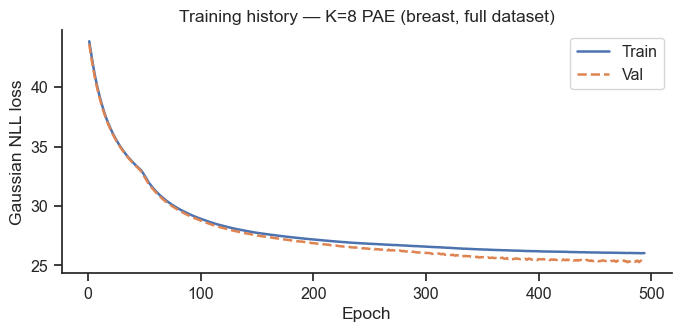

Final  train loss: 26.0335
Final  val   loss: 25.3069
Best   val   loss: 25.2690  (epoch 479)


In [74]:
fig, ax = plt.subplots(figsize=(7, 3.5))
ax.plot(hist_df['epoch'], hist_df['train_loss'], label='Train', lw=1.8)
ax.plot(hist_df['epoch'], hist_df['val_loss'],   label='Val',   lw=1.8, linestyle='--')
ax.set_xlabel('Epoch')
ax.set_ylabel('Gaussian NLL loss')
ax.set_title('Training history — K=8 PAE (breast, full dataset)')
ax.legend()
sns.despine()
plt.tight_layout()
plt.savefig(OUT_DIR / 'training_history.pdf', bbox_inches='tight')
plt.show()
print(f'Final  train loss: {hist_df["train_loss"].iloc[-1]:.4f}')
print(f'Final  val   loss: {hist_df["val_loss"].iloc[-1]:.4f}')
print(f'Best   val   loss: {hist_df["val_loss"].min():.4f}  (epoch {hist_df["val_loss"].idxmin()+1})')

---
## 3  Archetype latent-dimension loadings (component means)

Each row is an archetype; each column is a marker. Values are in the model's input space  
(clipped, normalized CyTOF intensities). Positive = high expression in that archetype.

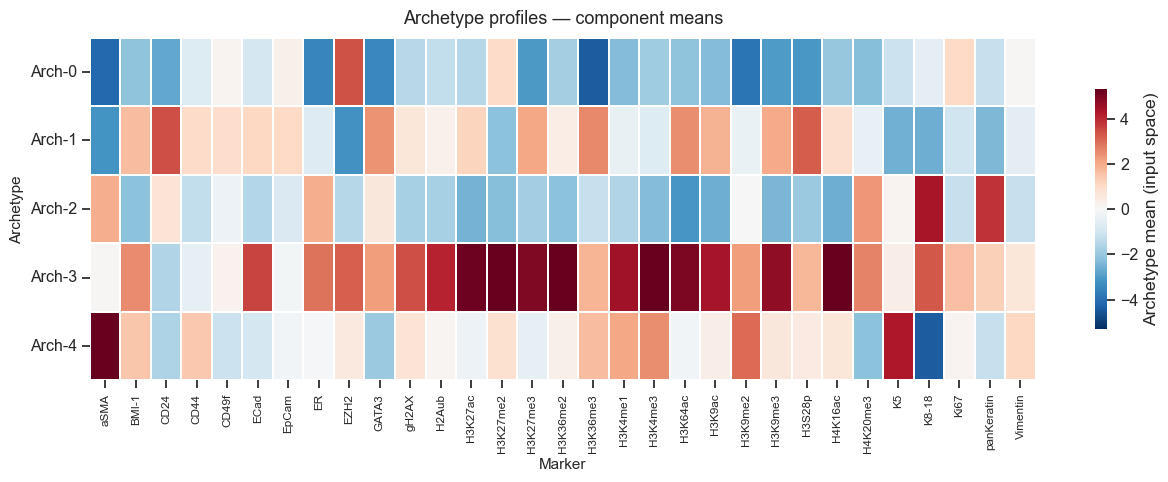

In [75]:
# ── Heatmap: archetypes × markers ─────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(13, 5))
vmax = np.abs(means_df.values).max() * 0.9
sns.heatmap(
    means_df,
    cmap='RdBu_r',
    center=0,
    vmin=-vmax, vmax=vmax,
    linewidths=0.3,
    linecolor='white',
    annot=False,
    ax=ax,
    cbar_kws={'label': 'Archetype mean (input space)', 'shrink': 0.7},
)
ax.set_title('Archetype profiles — component means', fontsize=13, pad=10)
ax.set_xlabel('Marker', fontsize=11)
ax.set_ylabel('Archetype', fontsize=11)
ax.tick_params(axis='x', rotation=90, labelsize=8.5)
ax.tick_params(axis='y', rotation=0)
plt.tight_layout()
plt.savefig(OUT_DIR / 'archetype_means_heatmap.pdf', bbox_inches='tight')
plt.show()

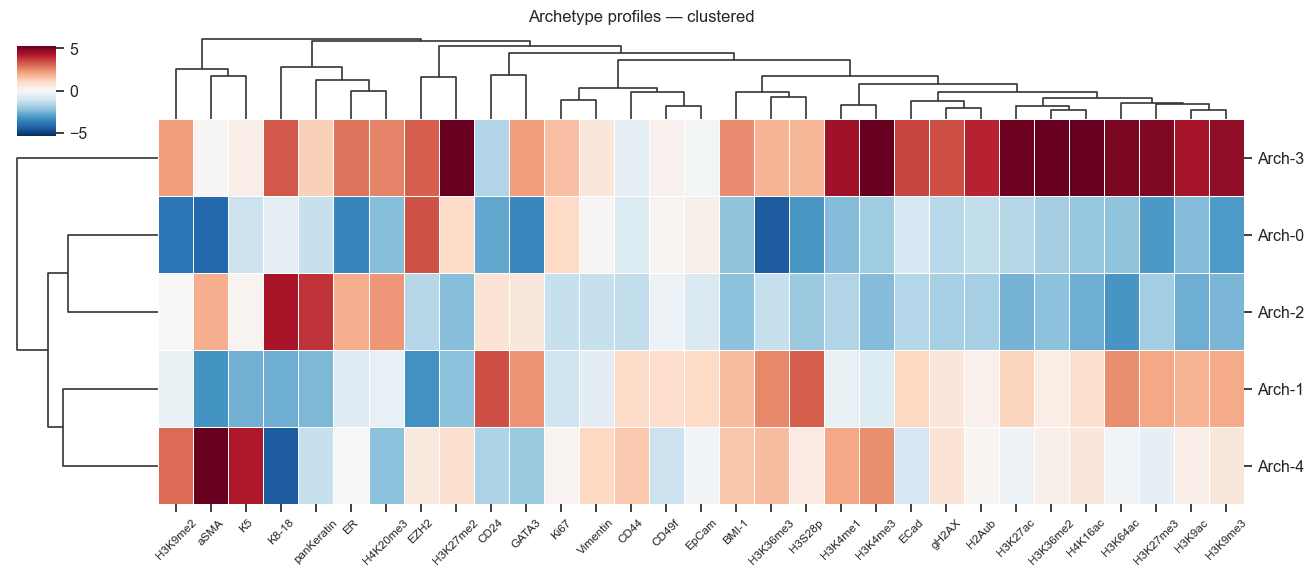

In [76]:
# ── Clustermap: cluster both archetypes and markers ────────────────────────────
vmax = np.abs(means_df.values).max() * 0.9
g = sns.clustermap(
    means_df,
    cmap='RdBu_r',
    center=0,
    vmin=-vmax, vmax=vmax,
    linewidths=0.4,
    linecolor='white',
    figsize=(13, 6),
    cbar_pos=(0.02, 0.8, 0.03, 0.15),
    tree_kws={'linewidths': 1.2},
    dendrogram_ratio=(0.12, 0.18),
)
g.ax_heatmap.tick_params(axis='x', rotation=45, labelsize=8.5)
g.ax_heatmap.tick_params(axis='y', rotation=0)
g.fig.suptitle('Archetype profiles — clustered', y=1.01, fontsize=12)
g.savefig(OUT_DIR / 'archetype_means_clustermap.pdf', bbox_inches='tight')
plt.show()

---
## 4  Archetype uncertainty (component variances)

The model learns per-archetype per-marker variances. High variance indicates  
large spread of cells assigned to that archetype along that marker axis.

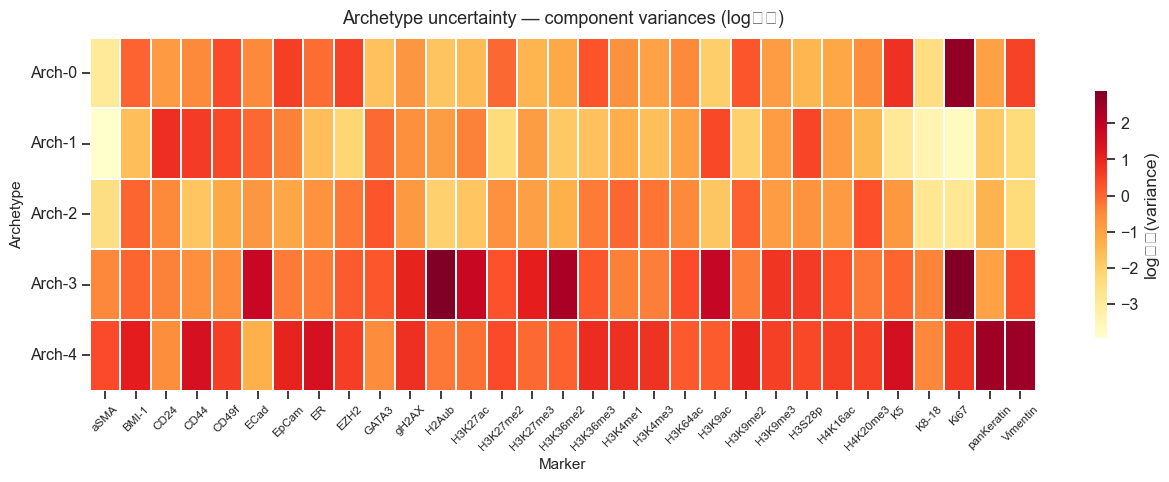

In [77]:
# Log10 of variance for readability
logvars_plot = np.log10(vars_df.clip(lower=1e-6))

fig, ax = plt.subplots(figsize=(13, 5))
sns.heatmap(
    logvars_plot,
    cmap='YlOrRd',
    linewidths=0.3,
    linecolor='white',
    ax=ax,
    cbar_kws={'label': 'log₁₀(variance)', 'shrink': 0.7},
)
ax.set_title('Archetype uncertainty — component variances (log₁₀)', fontsize=13, pad=10)
ax.set_xlabel('Marker', fontsize=11)
ax.set_ylabel('Archetype', fontsize=11)
ax.tick_params(axis='x', rotation=45, labelsize=8.5)
ax.tick_params(axis='y', rotation=0)
plt.tight_layout()
plt.savefig(OUT_DIR / 'archetype_vars_heatmap.pdf', bbox_inches='tight')
plt.show()

IndexError: single positional indexer is out-of-bounds

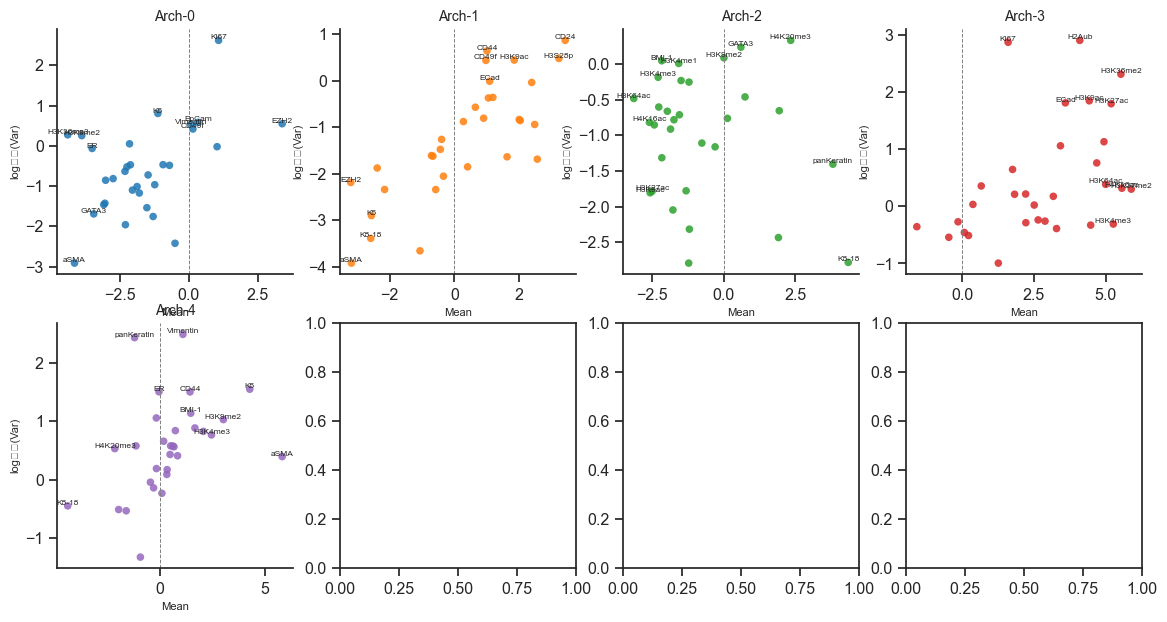

In [78]:
# ── Per-archetype: mean vs variance scatter ────────────────────────────────────
fig, axes = plt.subplots(2, 4, figsize=(14, 7), sharex=False, sharey=False)
for i, ax in enumerate(axes.flat):
    m = means_df.iloc[i].values
    v = np.log10(vars_df.iloc[i].values.clip(min=1e-6))
    ax.scatter(m, v, color=COMP_COLORS[i], s=30, alpha=0.85, edgecolors='none')
    for j, mk in enumerate(MARKERS):
        if abs(m[j]) > np.percentile(np.abs(m), 80) or v[j] > np.percentile(v, 80):
            ax.annotate(mk, (m[j], v[j]), fontsize=6, ha='center', va='bottom')
    ax.axvline(0, color='grey', lw=0.7, ls='--')
    ax.set_title(COMP_NAMES[i], fontsize=10)
    ax.set_xlabel('Mean', fontsize=8)
    ax.set_ylabel('log₁₀(Var)', fontsize=8)
    sns.despine(ax=ax)

plt.suptitle('Mean vs log-variance per marker, per archetype', fontsize=12, y=1.01)
plt.tight_layout()
plt.savefig(OUT_DIR / 'archetype_mean_vs_var.pdf', bbox_inches='tight')
plt.show()

---
## 5  Top marker loadings per archetype

IndexError: single positional indexer is out-of-bounds

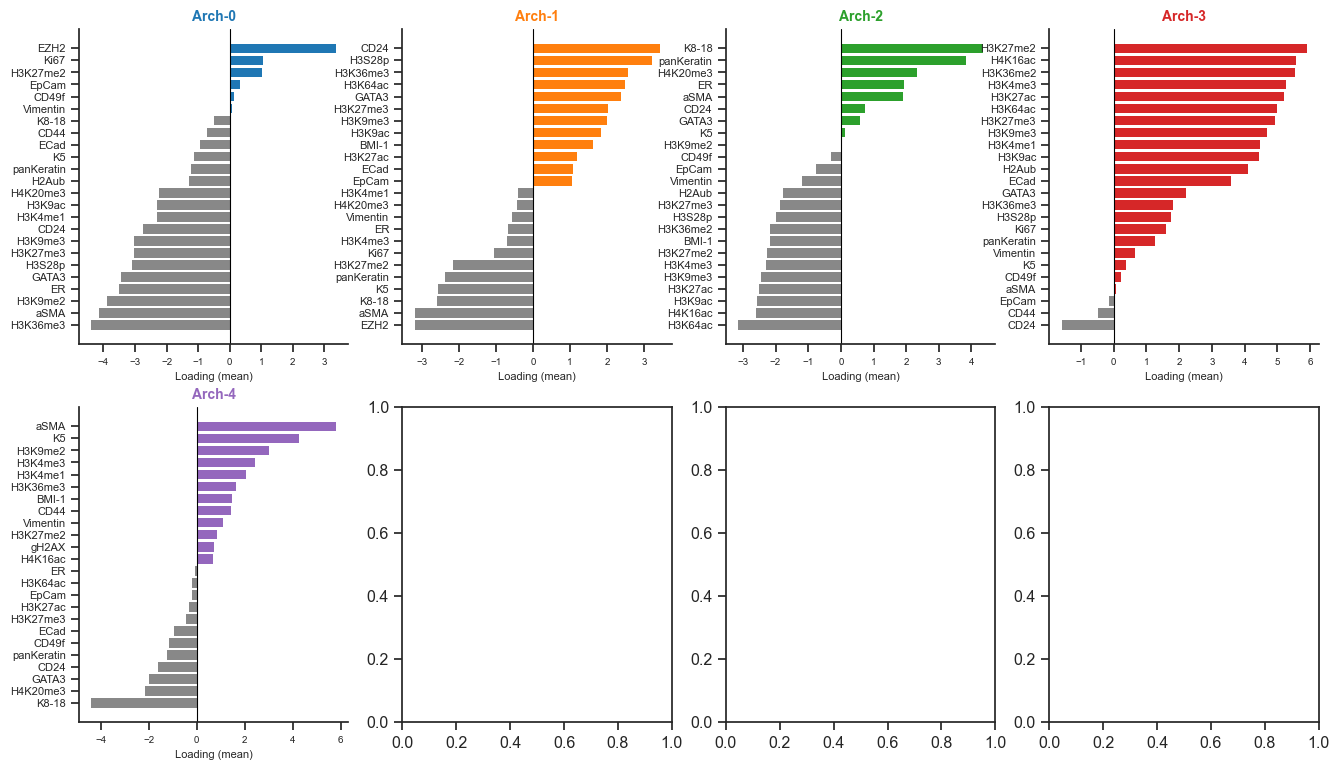

In [79]:
TOP_N = 12

fig, axes = plt.subplots(2, 4, figsize=(16, 9))
for i, ax in enumerate(axes.flat):
    loadings = means_df.iloc[i].sort_values()
    # pick top-N positive and top-N negative by absolute value
    top_pos = loadings.nlargest(TOP_N)
    top_neg = loadings.nsmallest(TOP_N)
    combined = pd.concat([top_neg, top_pos]).drop_duplicates()
    combined = combined.sort_values()

    colors = [COMP_COLORS[i] if v > 0 else '#888888' for v in combined.values]
    ax.barh(combined.index, combined.values, color=colors, edgecolor='none')
    ax.axvline(0, color='black', lw=0.8)
    ax.set_title(f'{COMP_NAMES[i]}', fontsize=10, color=COMP_COLORS[i], fontweight='bold')
    ax.tick_params(axis='y', labelsize=8)
    ax.tick_params(axis='x', labelsize=7)
    ax.set_xlabel('Loading (mean)', fontsize=8)
    sns.despine(ax=ax)

plt.suptitle(f'Top {TOP_N} positive + negative marker loadings per archetype', fontsize=13, y=1.01)
plt.tight_layout()
plt.savefig(OUT_DIR / 'top_marker_loadings.pdf', bbox_inches='tight')
plt.show()

In [80]:
# ── Summary table: top-5 positive markers per archetype ───────────────────────
records = []
for i in range(N_ARCHETYPES):
    top5 = means_df.iloc[i].nlargest(5)
    records.append({
        'Archetype': COMP_NAMES[i],
        'Top markers (+)': ', '.join([f'{m} ({v:.2f})' for m, v in top5.items()]),
    })
    top5n = means_df.iloc[i].nsmallest(5)
    records[-1]['Top markers (-)'] = ', '.join([f'{m} ({v:.2f})' for m, v in top5n.items()])

summary_tbl = pd.DataFrame(records)
summary_tbl.to_csv(OUT_DIR / 'archetype_top_markers.csv', index=False)
display(summary_tbl)

,Archetype,Top markers (+),Top markers (-)
0,Arch-0,"EZH2 (3.38), Ki67 (1.07), H3K27me2 (1.02), EpC...","H3K36me3 (-4.39), aSMA (-4.15), H3K9me2 (-3.88..."
1,Arch-1,"CD24 (3.42), H3S28p (3.23), H3K36me3 (2.56), H...","EZH2 (-3.20), aSMA (-3.18), K8-18 (-2.59), K5 ..."
2,Arch-2,"K8-18 (4.36), panKeratin (3.82), H4K20me3 (2.3...","H3K64ac (-3.15), H4K16ac (-2.60), H3K9ac (-2.5..."
3,Arch-3,"H3K27me2 (5.89), H4K16ac (5.56), H3K36me2 (5.5...","CD24 (-1.59), CD44 (-0.48), EpCam (-0.15), aSM..."
4,Arch-4,"aSMA (5.81), K5 (4.27), H3K9me2 (3.01), H3K4me...","K8-18 (-4.40), H4K20me3 (-2.16), GATA3 (-1.98)..."


---
## 6  Cell deconvolution overview: weight distributions and entropy

KeyError: 'w_5'

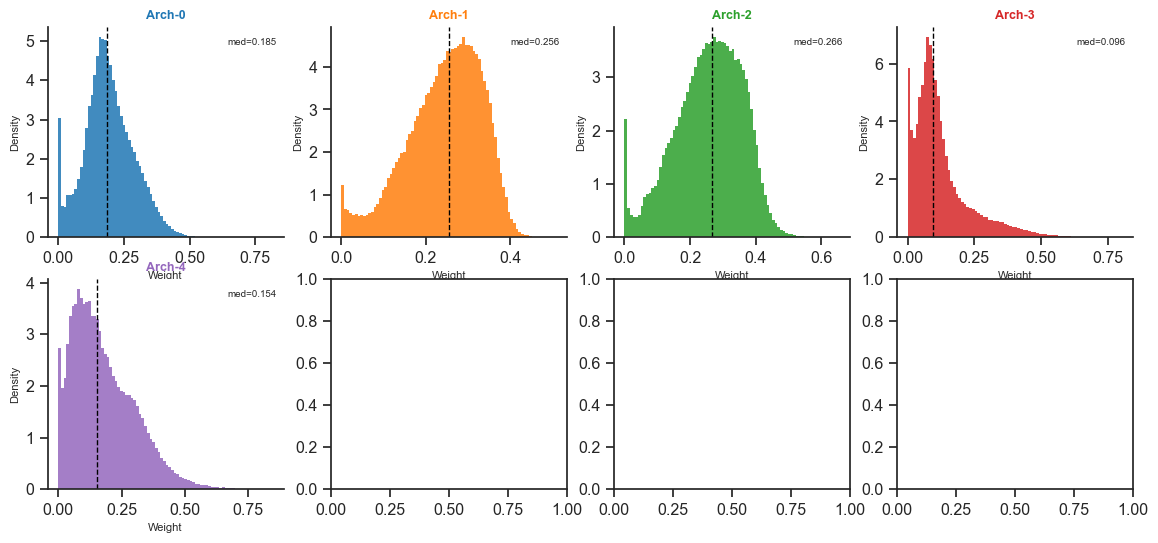

In [81]:
# ── Per-archetype weight distributions (all cells) ────────────────────────────
# Sample for speed; full dataset is 1.1M cells
sample_size = min(200_000, len(w_all))
w_sample = w_all.sample(sample_size, random_state=42)

fig, axes = plt.subplots(2, 4, figsize=(14, 6), sharey=False)
for i, ax in enumerate(axes.flat):
    col = f'w_{i}'
    ax.hist(w_sample[col].values, bins=80, color=COMP_COLORS[i],
            edgecolor='none', alpha=0.85, density=True)
    ax.set_title(COMP_NAMES[i], fontsize=9, color=COMP_COLORS[i], fontweight='bold')
    ax.set_xlabel('Weight', fontsize=8)
    ax.set_ylabel('Density', fontsize=8)
    med = w_sample[col].median()
    ax.axvline(med, color='black', lw=1, ls='--')
    ax.text(0.97, 0.95, f'med={med:.3f}', transform=ax.transAxes,
            ha='right', va='top', fontsize=7)
    sns.despine(ax=ax)

plt.suptitle(f'Per-archetype weight distributions (n={sample_size:,} cells sampled)', fontsize=12, y=1.01)
plt.tight_layout()
plt.savefig(OUT_DIR / 'weight_distributions.pdf', bbox_inches='tight')
plt.show()

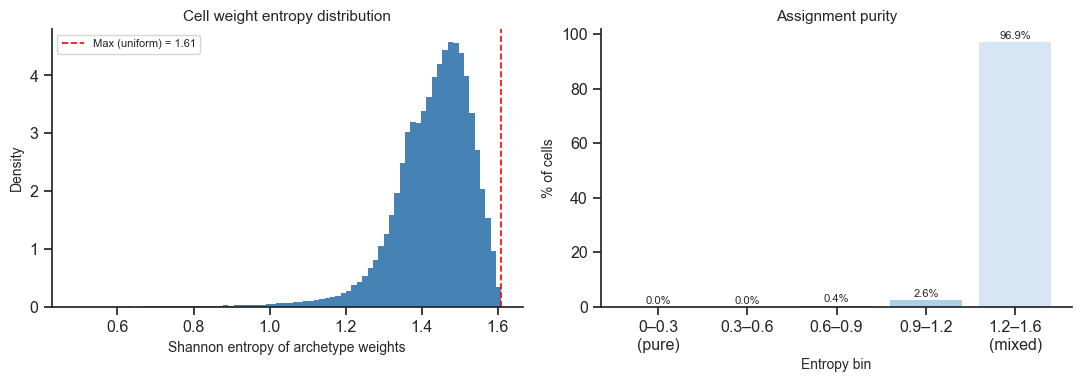

Mean entropy  : 1.428  (max = 1.609)
Median entropy: 1.445
Pure cells (H<0.3)  : 0.0%
Mixed cells (H>1.2) : 96.9%


In [82]:
# ── Weight entropy: how mixed vs pure are cell assignments? ───────────────────
fig, axes = plt.subplots(1, 2, figsize=(11, 4))

# Full entropy distribution
ax = axes[0]
ax.hist(w_sample['entropy'].values, bins=80, color='steelblue',
        edgecolor='none', density=True)
max_entropy = np.log(N_ARCHETYPES)  # maximum possible (uniform)
ax.axvline(max_entropy, color='red', lw=1.2, ls='--', label=f'Max (uniform) = {max_entropy:.2f}')
ax.set_xlabel('Shannon entropy of archetype weights', fontsize=10)
ax.set_ylabel('Density', fontsize=10)
ax.set_title('Cell weight entropy distribution', fontsize=11)
ax.legend(fontsize=8)
sns.despine(ax=ax)

# Fraction pure (entropy < 0.3) vs mixed (entropy > max*0.8)
ax = axes[1]
ent = w_sample['entropy'].values
thresholds = [0, 0.3, 0.6, 0.9, 1.2, max_entropy + 0.01]
labels_bins = ['0–0.3\n(pure)', '0.3–0.6', '0.6–0.9', '0.9–1.2', f'1.2–{max_entropy:.1f}\n(mixed)']
counts, _ = np.histogram(ent, bins=thresholds)
pcts = counts / counts.sum() * 100
bars = ax.bar(labels_bins, pcts, color=sns.color_palette('Blues_r', 5), edgecolor='none')
for bar, pct in zip(bars, pcts):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.5,
            f'{pct:.1f}%', ha='center', va='bottom', fontsize=8)
ax.set_xlabel('Entropy bin', fontsize=10)
ax.set_ylabel('% of cells', fontsize=10)
ax.set_title('Assignment purity', fontsize=11)
sns.despine(ax=ax)

plt.tight_layout()
plt.savefig(OUT_DIR / 'weight_entropy.pdf', bbox_inches='tight')
plt.show()

print(f'Mean entropy  : {ent.mean():.3f}  (max = {max_entropy:.3f})')
print(f'Median entropy: {np.median(ent):.3f}')
print(f'Pure cells (H<0.3)  : {(ent < 0.3).mean()*100:.1f}%')
print(f'Mixed cells (H>1.2) : {(ent > 1.2).mean()*100:.1f}%')

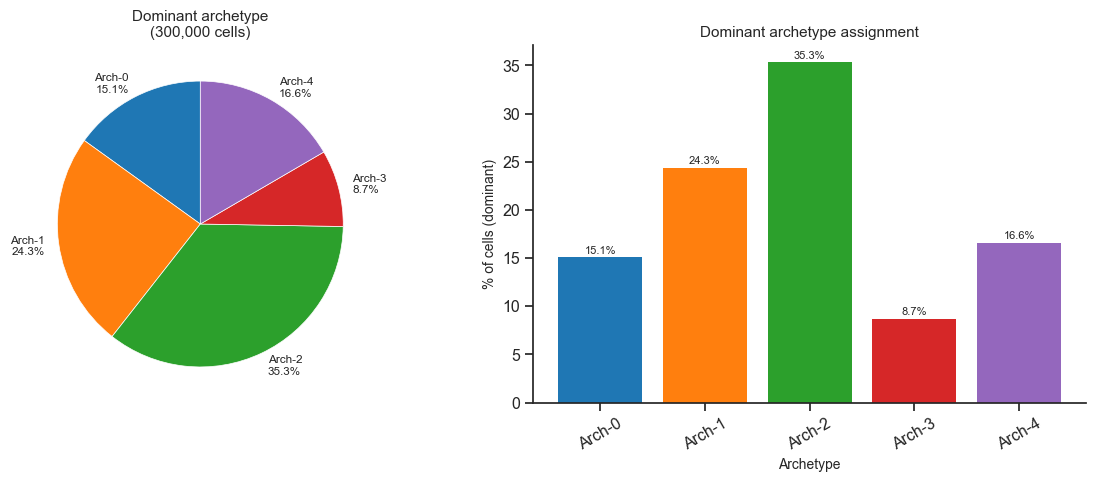

In [83]:
# ── Dominant archetype assignment across all cells ─────────────────────────────
dom_counts = w_all['dominant'].value_counts().sort_index()

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Pie chart
ax = axes[0]
wedge_labels = [f'{COMP_NAMES[i]}\n{dom_counts.get(i,0)/len(w_all)*100:.1f}%'
                for i in range(N_ARCHETYPES)]
ax.pie([dom_counts.get(i, 0) for i in range(N_ARCHETYPES)],
       labels=wedge_labels, colors=COMP_COLORS,
       startangle=90, wedgeprops={'linewidth': 0.5, 'edgecolor': 'white'},
       textprops={'fontsize': 8.5})
ax.set_title(f'Dominant archetype\n({len(w_all):,} cells)', fontsize=11)

# Bar chart
ax = axes[1]
fracs = [dom_counts.get(i, 0) / len(w_all) * 100 for i in range(N_ARCHETYPES)]
bars = ax.bar(COMP_NAMES, fracs, color=COMP_COLORS, edgecolor='none')
for bar, f in zip(bars, fracs):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.2,
            f'{f:.1f}%', ha='center', va='bottom', fontsize=8)
ax.set_xlabel('Archetype', fontsize=10)
ax.set_ylabel('% of cells (dominant)', fontsize=10)
ax.set_title('Dominant archetype assignment', fontsize=11)
ax.tick_params(axis='x', rotation=30)
sns.despine(ax=ax)

plt.tight_layout()
plt.savefig(OUT_DIR / 'dominant_archetype.pdf', bbox_inches='tight')
plt.show()

---
## 7  Per-sample deconvolution

Using val + test cells (which have traceable cell IDs → sample metadata).

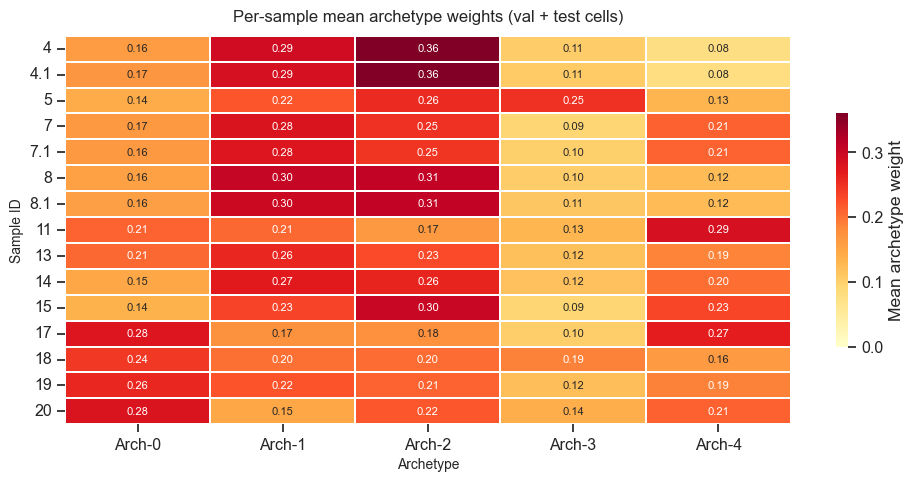

In [84]:
# ── Mean archetype weight per sample ──────────────────────────────────────────
sample_means = (
    w_valtest.groupby('sample_id')[WEIGHT_COLS].mean()
    .reindex(SAMPLES)
)
sample_means.columns = COMP_NAMES

fig, ax = plt.subplots(figsize=(10, 5))
sns.heatmap(
    sample_means,
    cmap='YlOrRd',
    vmin=0,
    linewidths=0.3,
    linecolor='white',
    annot=True,
    fmt='.2f',
    annot_kws={'size': 8},
    ax=ax,
    cbar_kws={'label': 'Mean archetype weight', 'shrink': 0.6},
)
ax.set_title('Per-sample mean archetype weights (val + test cells)', fontsize=12, pad=10)
ax.set_xlabel('Archetype', fontsize=10)
ax.set_ylabel('Sample ID', fontsize=10)
ax.tick_params(axis='y', rotation=0)
plt.tight_layout()
plt.savefig(OUT_DIR / 'per_sample_mean_weights_heatmap.pdf', bbox_inches='tight')
plt.show()

sample_means.to_csv(OUT_DIR / 'per_sample_mean_weights.csv')

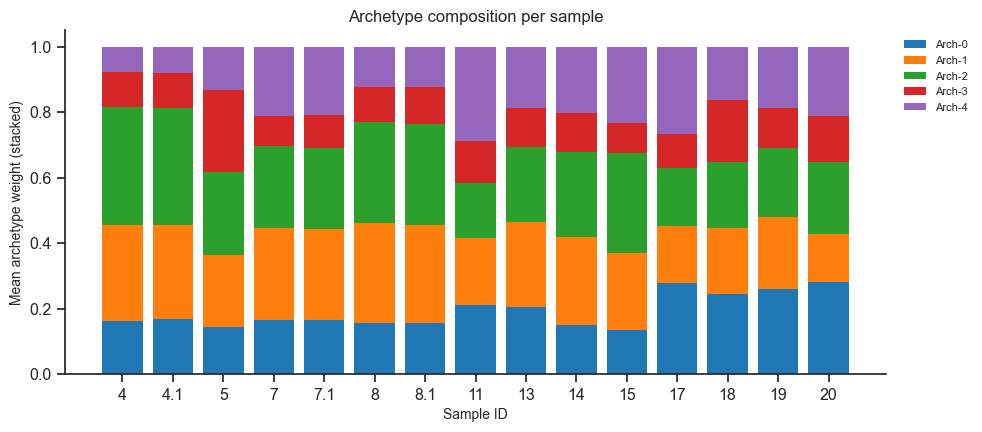

In [85]:
# ── Stacked bar: composition per sample ───────────────────────────────────────
fig, ax = plt.subplots(figsize=(10, 4.5))
bottom = np.zeros(len(SAMPLES))
for i, col in enumerate(COMP_NAMES):
    vals = sample_means[col].values
    ax.bar(SAMPLES, vals, bottom=bottom, color=COMP_COLORS[i], label=col, edgecolor='none')
    bottom += vals
ax.set_xlabel('Sample ID', fontsize=10)
ax.set_ylabel('Mean archetype weight (stacked)', fontsize=10)
ax.set_title('Archetype composition per sample', fontsize=12)
ax.legend(bbox_to_anchor=(1.01, 1), loc='upper left', fontsize=8, frameon=False)
sns.despine(ax=ax)
plt.tight_layout()
plt.savefig(OUT_DIR / 'per_sample_stacked_bar.pdf', bbox_inches='tight')
plt.show()

IndexError: list index out of range

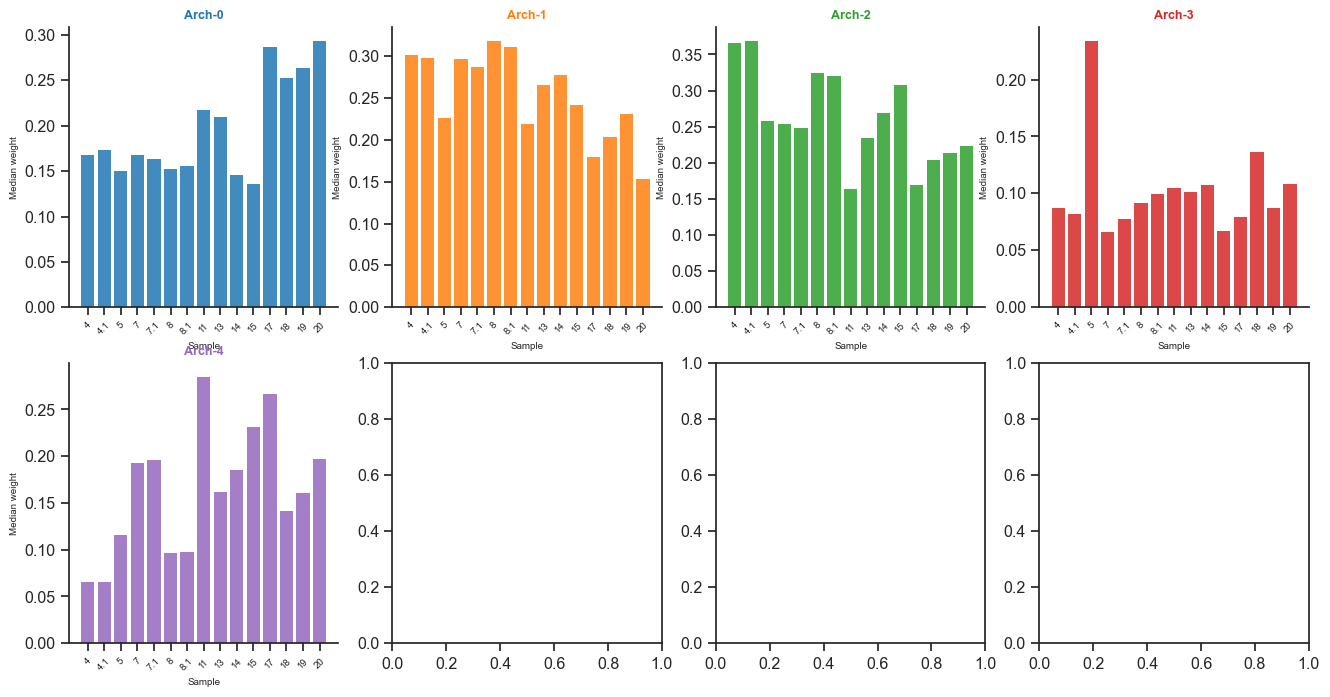

In [86]:
# ── Box plots: weight distributions per archetype, split by sample ─────────────
# Melt to long format for seaborn
w_long = w_valtest[['sample_id'] + WEIGHT_COLS].melt(
    id_vars='sample_id', value_vars=WEIGHT_COLS,
    var_name='component_col', value_name='weight'
)
w_long['archetype'] = w_long['component_col'].map(
    {f'w_{i}': COMP_NAMES[i] for i in range(N_ARCHETYPES)})

fig, axes = plt.subplots(2, 4, figsize=(16, 8), sharey=False)
for i, ax in enumerate(axes.flat):
    sub = w_long[w_long['archetype'] == COMP_NAMES[i]]
    sub_s = sub.groupby('sample_id')['weight'].median().reindex(SAMPLES)
    ax.bar(SAMPLES, sub_s.values, color=COMP_COLORS[i], edgecolor='none', alpha=0.85)
    ax.set_title(COMP_NAMES[i], fontsize=9, color=COMP_COLORS[i], fontweight='bold')
    ax.set_xlabel('Sample', fontsize=7)
    ax.set_ylabel('Median weight', fontsize=7)
    ax.tick_params(axis='x', rotation=45, labelsize=7)
    sns.despine(ax=ax)

plt.suptitle('Median archetype weight per sample', fontsize=12, y=1.01)
plt.tight_layout()
plt.savefig(OUT_DIR / 'per_sample_per_arch_bars.pdf', bbox_inches='tight')
plt.show()

---
## 8  UMAP of cell weights

Embedding the 8-dimensional weight vectors into 2D using UMAP.  
Cells are subsampled to 60k for computational feasibility.

In [87]:
# ── Subsample and fit UMAP ─────────────────────────────────────────────────────
UMAP_N = 60_000
rng    = np.random.default_rng(42)

# We want a mix of all splits; prefer val+test (annotated) but top-up with train
n_valtest = min(UMAP_N, len(w_valtest))
idx_vt = rng.choice(len(w_valtest), size=n_valtest, replace=False)
umap_df = w_valtest.iloc[idx_vt].copy().reset_index(drop=True)

X_umap = umap_df[WEIGHT_COLS].values.astype(np.float32)

print(f'Fitting UMAP on {len(umap_df):,} cells (8D weights)...')
reducer = umap.UMAP(
    n_components=2,
    n_neighbors=30,
    min_dist=0.1,
    metric='euclidean',
    random_state=42,
    verbose=True,
)
embedding = reducer.fit_transform(X_umap)
umap_df['UMAP1'] = embedding[:, 0]
umap_df['UMAP2'] = embedding[:, 1]
umap_df['dominant'] = X_umap.argmax(axis=1)
print('Done.')

Fitting UMAP on 60,000 cells (8D weights)...
UMAP(n_jobs=1, n_neighbors=30, random_state=42, verbose=True)
Tue Apr  7 13:00:15 2026 Construct fuzzy simplicial set
Tue Apr  7 13:00:15 2026 Finding Nearest Neighbors
Tue Apr  7 13:00:15 2026 Building RP forest with 17 trees
Tue Apr  7 13:00:15 2026 NN descent for 16 iterations
	 1  /  16
	 2  /  16
	Stopping threshold met -- exiting after 2 iterations
Tue Apr  7 13:00:17 2026 Finished Nearest Neighbor Search
Tue Apr  7 13:00:17 2026 Construct embedding


Epochs completed:   0%|            0/200 [00:00]

	completed  0  /  200 epochs
	completed  20  /  200 epochs
	completed  40  /  200 epochs
	completed  60  /  200 epochs
	completed  80  /  200 epochs
	completed  100  /  200 epochs
	completed  120  /  200 epochs
	completed  140  /  200 epochs
	completed  160  /  200 epochs
	completed  180  /  200 epochs
Tue Apr  7 13:00:40 2026 Finished embedding
Done.


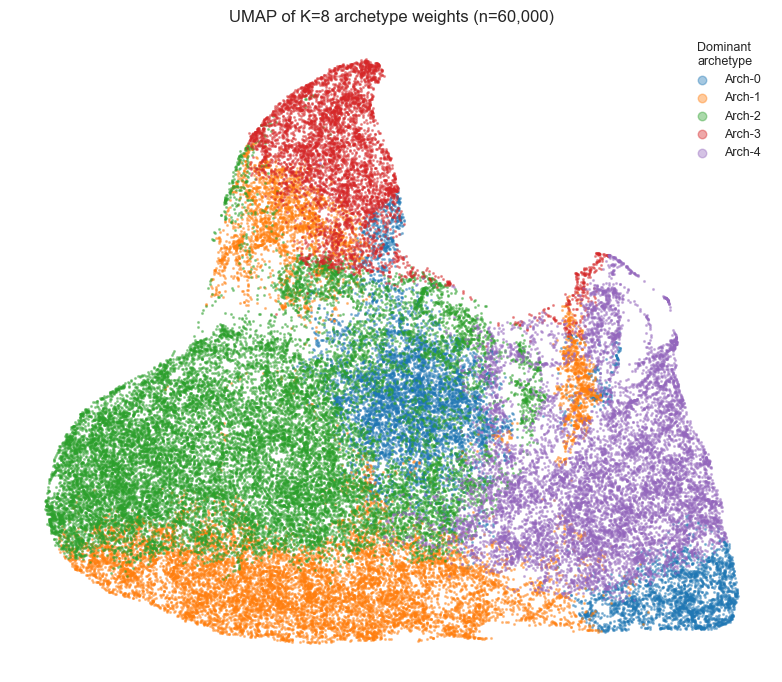

In [88]:
# ── UMAP coloured by dominant archetype ───────────────────────────────────────
fig, ax = plt.subplots(figsize=(8, 7))
for i in range(N_ARCHETYPES):
    mask = umap_df['dominant'] == i
    ax.scatter(
        umap_df.loc[mask, 'UMAP1'], umap_df.loc[mask, 'UMAP2'],
        c=[COMP_COLORS[i]], s=1.5, alpha=0.4, label=COMP_NAMES[i], rasterized=True
    )
ax.set_xlabel('UMAP 1', fontsize=10)
ax.set_ylabel('UMAP 2', fontsize=10)
ax.set_title(f'UMAP of K=8 archetype weights (n={len(umap_df):,})', fontsize=12)
legend = ax.legend(
    loc='upper right', markerscale=5, fontsize=9, frameon=False,
    title='Dominant\narchetype', title_fontsize=9
)
ax.axis('off')
plt.tight_layout()
plt.savefig(OUT_DIR / 'umap_dominant_archetype.pdf', bbox_inches='tight', dpi=200)
plt.show()

KeyError: 'w_5'

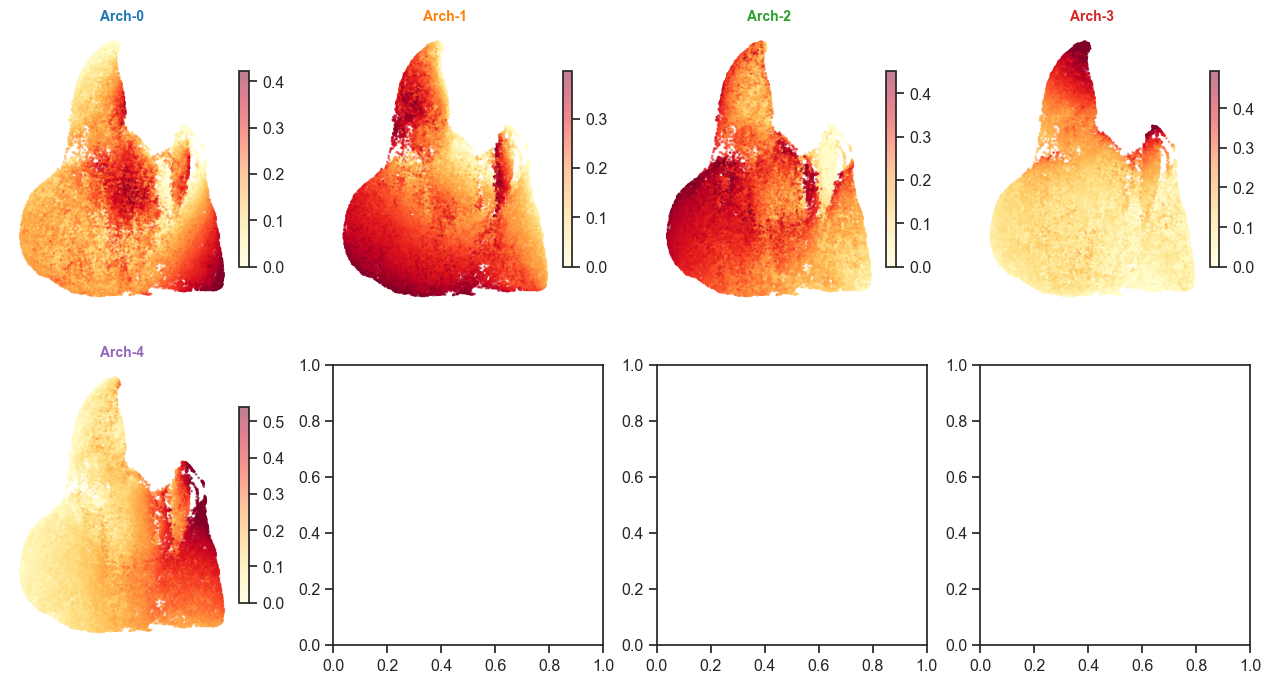

In [89]:
# ── UMAP: continuous weight per archetype (small multiples) ───────────────────
fig, axes = plt.subplots(2, 4, figsize=(16, 8))
for i, ax in enumerate(axes.flat):
    w_vals = umap_df[f'w_{i}'].values
    vmax_i = np.percentile(w_vals, 99)
    sc = ax.scatter(
        umap_df['UMAP1'], umap_df['UMAP2'],
        c=w_vals, cmap='YlOrRd', s=1.0, alpha=0.5,
        vmin=0, vmax=vmax_i,
        rasterized=True,
    )
    plt.colorbar(sc, ax=ax, shrink=0.7, pad=0.02)
    ax.set_title(COMP_NAMES[i], fontsize=10, color=COMP_COLORS[i], fontweight='bold')
    ax.axis('off')

plt.suptitle('UMAP coloured by per-archetype weight', fontsize=12, y=1.01)
plt.tight_layout()
plt.savefig(OUT_DIR / 'umap_per_archetype_weight.pdf', bbox_inches='tight', dpi=200)
plt.show()

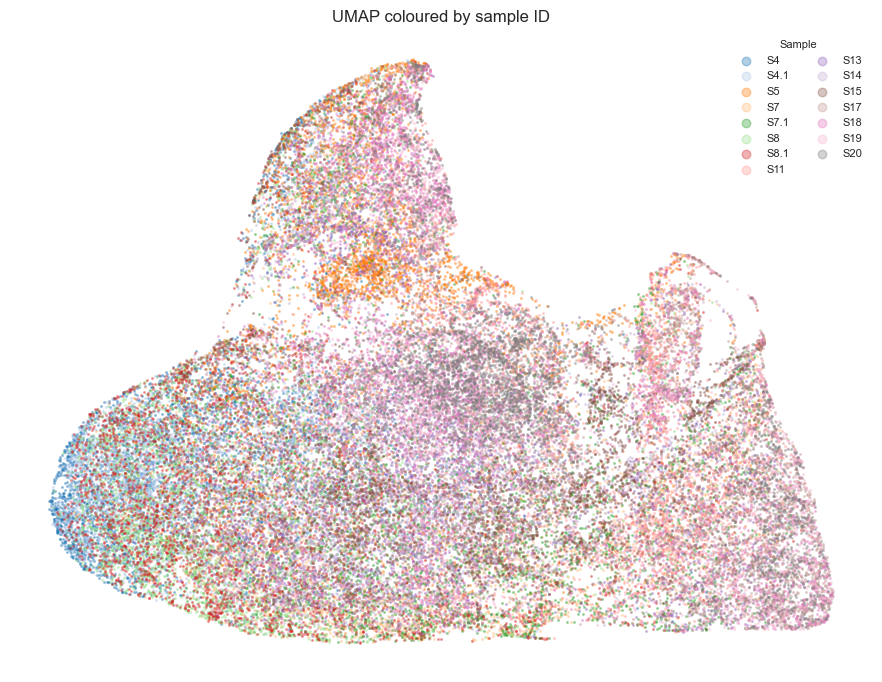

In [90]:
# ── UMAP coloured by sample ID ────────────────────────────────────────────────
sample_palette = dict(zip(SAMPLES, sns.color_palette('tab20', len(SAMPLES))))

fig, ax = plt.subplots(figsize=(9, 7))
for sid in SAMPLES:
    mask = umap_df['sample_id'] == sid
    ax.scatter(
        umap_df.loc[mask, 'UMAP1'], umap_df.loc[mask, 'UMAP2'],
        c=[sample_palette[sid]], s=1.5, alpha=0.35, label=f'S{sid}', rasterized=True
    )
ax.set_xlabel('UMAP 1', fontsize=10)
ax.set_ylabel('UMAP 2', fontsize=10)
ax.set_title(f'UMAP coloured by sample ID', fontsize=12)
ax.legend(loc='upper right', markerscale=5, fontsize=8, frameon=False,
          title='Sample', title_fontsize=8, ncol=2)
ax.axis('off')
plt.tight_layout()
plt.savefig(OUT_DIR / 'umap_sample_id.pdf', bbox_inches='tight', dpi=200)
plt.show()

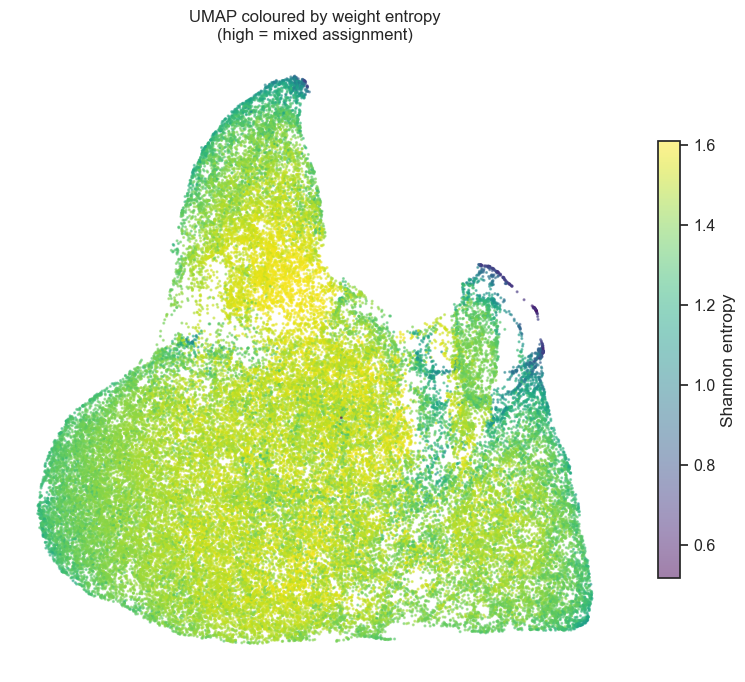

In [91]:
# ── UMAP coloured by weight entropy ───────────────────────────────────────────
fig, ax = plt.subplots(figsize=(8, 7))
sc = ax.scatter(
    umap_df['UMAP1'], umap_df['UMAP2'],
    c=umap_df['entropy'], cmap='viridis', s=1.5, alpha=0.5, rasterized=True
)
plt.colorbar(sc, ax=ax, label='Shannon entropy', shrink=0.7)
ax.set_title('UMAP coloured by weight entropy\n(high = mixed assignment)', fontsize=12)
ax.axis('off')
plt.tight_layout()
plt.savefig(OUT_DIR / 'umap_entropy.pdf', bbox_inches='tight', dpi=200)
plt.show()

---
## 9  Marker ↔ archetype correlations

Pearson and Spearman correlations between per-cell marker expression and archetype weights,  
computed on val + test cells.

In [92]:
# ── Load expression for val+test cells ────────────────────────────────────────
# Index adata by the annotated val+test cell IDs
cell_ids_vt = w_valtest['cell_id'].values
cell_mask   = adata.obs_names.isin(cell_ids_vt)
adata_vt    = adata[cell_mask].copy()

X_expr = pd.DataFrame(
    adata_vt.X,
    index=adata_vt.obs_names,
    columns=adata_vt.var_names,
)

# Align weights to same order
w_vt_aligned = w_valtest.set_index('cell_id').loc[adata_vt.obs_names, WEIGHT_COLS]

print(f'Expression matrix : {X_expr.shape}')
print(f'Weight matrix     : {w_vt_aligned.shape}')

Expression matrix : (90000, 31)
Weight matrix     : (90000, 5)


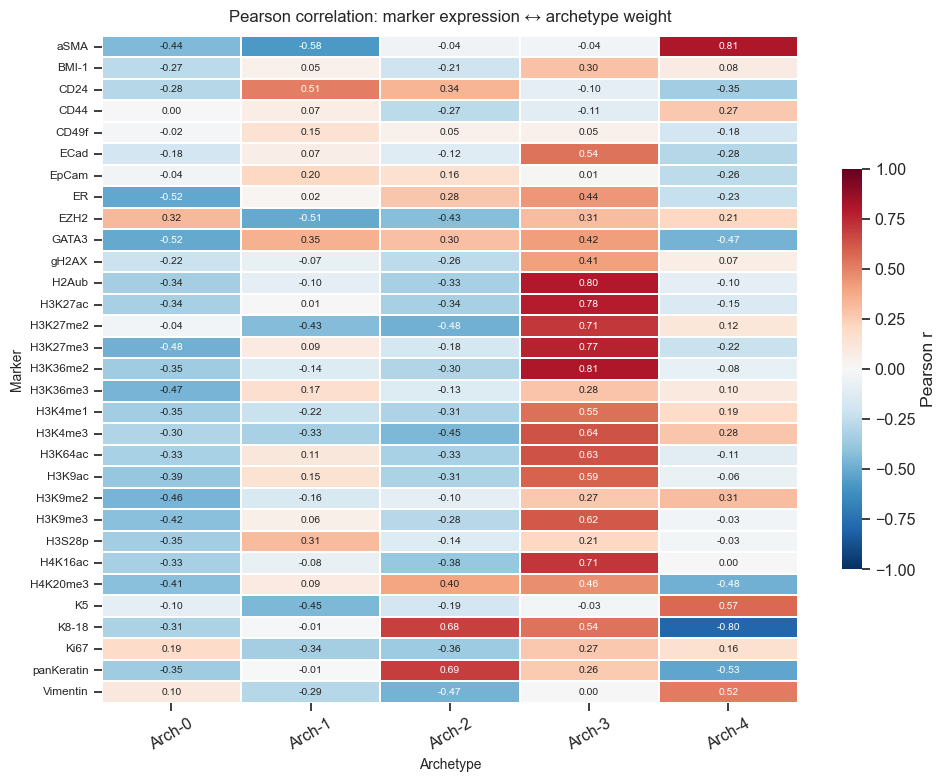

In [93]:
# ── Pearson correlation: markers × archetype weights ──────────────────────────
pearson_mat = np.corrcoef(X_expr.values.T, w_vt_aligned.values.T)
n_m = len(MARKERS)
# Upper-right block: markers (rows) vs weights (cols)
corr_pearson = pd.DataFrame(
    pearson_mat[:n_m, n_m:],
    index=MARKERS,
    columns=COMP_NAMES,
)

fig, ax = plt.subplots(figsize=(10, 8))
sns.heatmap(
    corr_pearson,
    cmap='RdBu_r',
    center=0,
    vmin=-1, vmax=1,
    linewidths=0.3,
    linecolor='white',
    annot=True,
    fmt='.2f',
    annot_kws={'size': 7.5},
    ax=ax,
    cbar_kws={'label': 'Pearson r', 'shrink': 0.6},
)
ax.set_title('Pearson correlation: marker expression ↔ archetype weight', fontsize=12, pad=10)
ax.set_xlabel('Archetype', fontsize=10)
ax.set_ylabel('Marker', fontsize=10)
ax.tick_params(axis='x', rotation=30)
ax.tick_params(axis='y', labelsize=8.5)
plt.tight_layout()
plt.savefig(OUT_DIR / 'marker_archetype_pearson.pdf', bbox_inches='tight')
plt.show()
corr_pearson.to_csv(OUT_DIR / 'marker_archetype_pearson.csv')

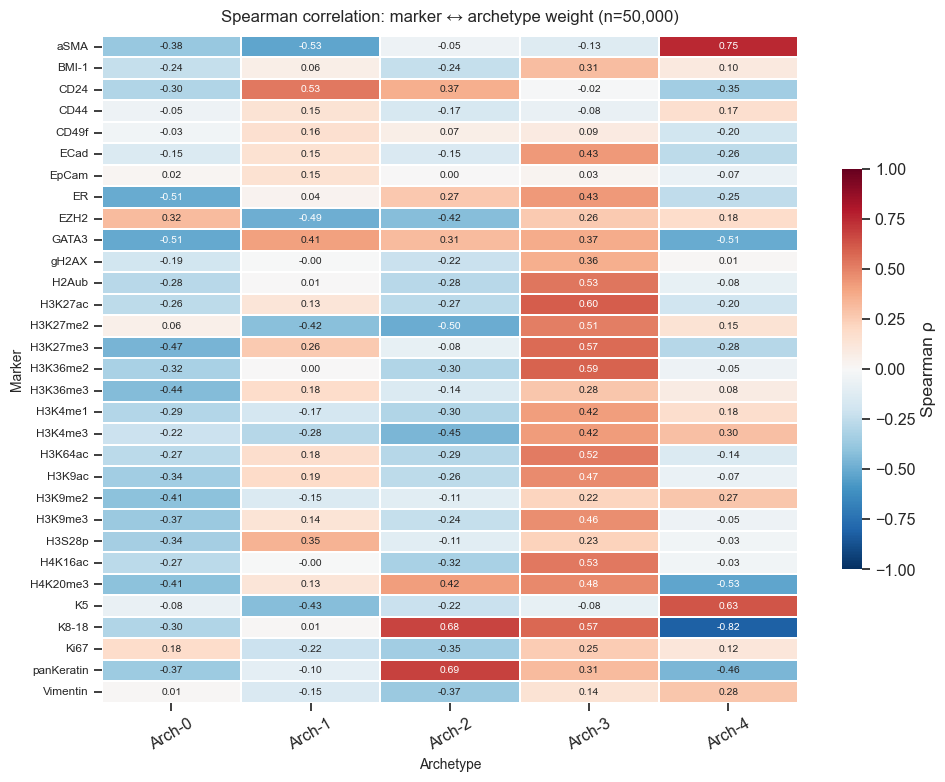

In [94]:
# ── Spearman correlation ───────────────────────────────────────────────────────
from scipy.stats import spearmanr

# Subsample for speed (full correlation on 340k cells is slow)
CORR_N = min(50_000, len(X_expr))
idx_c  = rng.choice(len(X_expr), size=CORR_N, replace=False)
X_sub  = X_expr.iloc[idx_c].values
W_sub  = w_vt_aligned.iloc[idx_c].values

spearman_vals = np.zeros((len(MARKERS), N_ARCHETYPES))
for mi, marker in enumerate(MARKERS):
    for ai in range(N_ARCHETYPES):
        r, _ = spearmanr(X_sub[:, mi], W_sub[:, ai])
        spearman_vals[mi, ai] = r

corr_spearman = pd.DataFrame(spearman_vals, index=MARKERS, columns=COMP_NAMES)

fig, ax = plt.subplots(figsize=(10, 8))
sns.heatmap(
    corr_spearman,
    cmap='RdBu_r',
    center=0,
    vmin=-1, vmax=1,
    linewidths=0.3,
    linecolor='white',
    annot=True,
    fmt='.2f',
    annot_kws={'size': 7.5},
    ax=ax,
    cbar_kws={'label': 'Spearman ρ', 'shrink': 0.6},
)
ax.set_title(f'Spearman correlation: marker ↔ archetype weight (n={CORR_N:,})', fontsize=12, pad=10)
ax.set_xlabel('Archetype', fontsize=10)
ax.set_ylabel('Marker', fontsize=10)
ax.tick_params(axis='x', rotation=30)
ax.tick_params(axis='y', labelsize=8.5)
plt.tight_layout()
plt.savefig(OUT_DIR / 'marker_archetype_spearman.pdf', bbox_inches='tight')
plt.show()
corr_spearman.to_csv(OUT_DIR / 'marker_archetype_spearman.csv')

In [95]:
# ── Top marker-archetype pairs by |Spearman ρ| ────────────────────────────────
corr_long = (
    corr_spearman.reset_index()
    .melt(id_vars='index', var_name='archetype', value_name='spearman_rho')
    .rename(columns={'index': 'marker'})
)
corr_long['abs_rho'] = corr_long['spearman_rho'].abs()
top_pairs = corr_long.nlargest(20, 'abs_rho')

print('Top 20 marker–archetype correlations (|Spearman ρ|):')
display(top_pairs[['marker', 'archetype', 'spearman_rho']].reset_index(drop=True))

Top 20 marker–archetype correlations (|Spearman ρ|):


,marker,archetype,spearman_rho
0,K8-18,Arch-4,-0.819857
1,aSMA,Arch-4,0.752564
2,panKeratin,Arch-2,0.685701
3,K8-18,Arch-2,0.675899
4,K5,Arch-4,0.629255
5,H3K27ac,Arch-3,0.603211
6,H3K36me2,Arch-3,0.586110
7,K8-18,Arch-3,0.573196
8,H3K27me3,Arch-3,0.569760
9,H2Aub,Arch-3,0.533624


---
## 10  Reconstruction quality

In [96]:
# ── Load test reconstructions and logvars ─────────────────────────────────────
# reconstructions.csv rows correspond to the same order as test/weights.csv
recon_arr   = pd.read_csv(RUN_DIR / 'test/reconstructions.csv')[MARKERS].values.astype(np.float32)
logvars_arr = pd.read_csv(RUN_DIR / 'test/logvars.csv')[MARKERS].values.astype(np.float32)

# Get ground-truth expression for test cells, in same order as weights.csv
test_cell_ids = w_test['cell_id'].values          # order from test/weights.csv
adata_test    = adata[adata.obs_names.isin(test_cell_ids)].copy()
expr_reindexed = pd.DataFrame(
    adata_test.X,
    index=adata_test.obs_names,
    columns=adata_test.var_names,
).reindex(test_cell_ids)                           # align to weights.csv row order

X_true  = expr_reindexed.values.astype(np.float32)
X_recon = recon_arr

mse_per_cell = ((X_true - X_recon) ** 2).mean(axis=1)
mae_per_cell = np.abs(X_true - X_recon).mean(axis=1)
nll_per_cell = 0.5 * (
    logvars_arr + (X_true - X_recon) ** 2 * np.exp(-logvars_arr) + np.log(2 * np.pi)
).mean(axis=1)

print(f'Test cells        : {len(X_true):,}')
print(f'Mean MSE per cell : {mse_per_cell.mean():.4f}')
print(f'Mean MAE per cell : {mae_per_cell.mean():.4f}')
print(f'Mean NLL per cell : {nll_per_cell.mean():.4f}')

Test cells        : 45,000
Mean MSE per cell : 0.5504
Mean MAE per cell : 0.5258
Mean NLL per cell : 0.8140


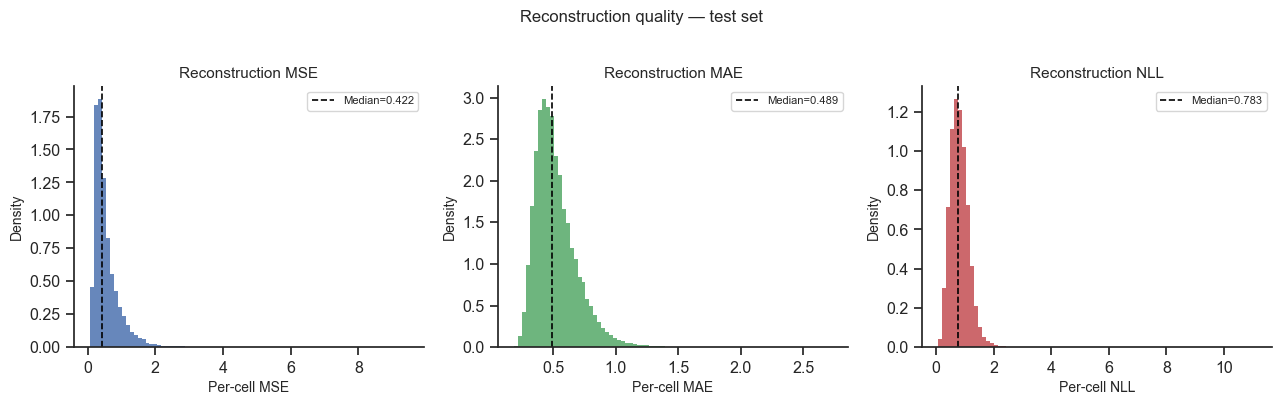

In [97]:
# ── Distribution of per-cell MSE and NLL ──────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(13, 4))

for ax, vals, label, color in zip(
    axes,
    [mse_per_cell, mae_per_cell, nll_per_cell],
    ['MSE', 'MAE', 'NLL'],
    ['#4c72b0', '#55a868', '#c44e52'],
):
    ax.hist(vals, bins=80, color=color, edgecolor='none', density=True, alpha=0.85)
    ax.axvline(np.median(vals), color='black', lw=1.2, ls='--',
               label=f'Median={np.median(vals):.3f}')
    ax.set_xlabel(f'Per-cell {label}', fontsize=10)
    ax.set_ylabel('Density', fontsize=10)
    ax.set_title(f'Reconstruction {label}', fontsize=11)
    ax.legend(fontsize=8)
    sns.despine(ax=ax)

plt.suptitle('Reconstruction quality — test set', fontsize=12, y=1.01)
plt.tight_layout()
plt.savefig(OUT_DIR / 'reconstruction_quality_hist.pdf', bbox_inches='tight')
plt.show()

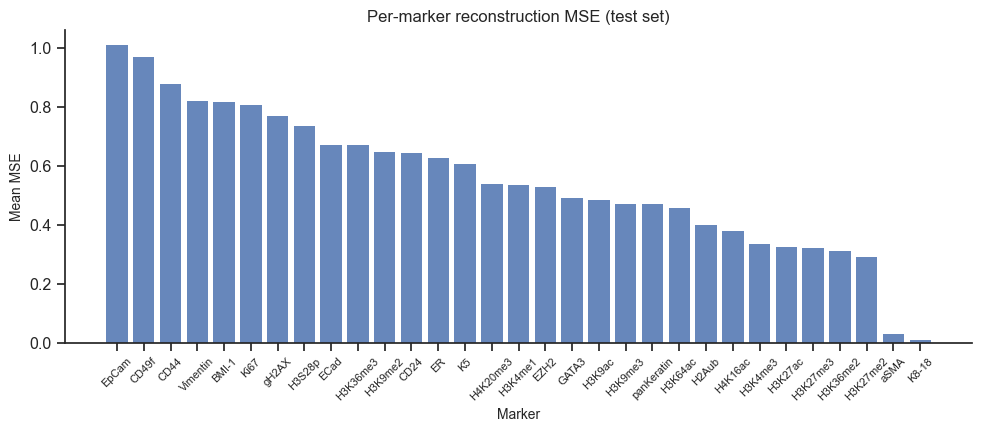

In [98]:
# ── Per-marker reconstruction MSE ─────────────────────────────────────────────
mse_per_marker = ((X_true - X_recon)**2).mean(axis=0)
marker_mse_df  = pd.Series(mse_per_marker, index=MARKERS).sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(10, 4.5))
bars = ax.bar(marker_mse_df.index, marker_mse_df.values,
              color='#4c72b0', edgecolor='none', alpha=0.85)
ax.set_xlabel('Marker', fontsize=10)
ax.set_ylabel('Mean MSE', fontsize=10)
ax.set_title('Per-marker reconstruction MSE (test set)', fontsize=12)
ax.tick_params(axis='x', rotation=45, labelsize=8)
sns.despine(ax=ax)
plt.tight_layout()
plt.savefig(OUT_DIR / 'reconstruction_per_marker_mse.pdf', bbox_inches='tight')
plt.show()

marker_mse_df.to_csv(OUT_DIR / 'reconstruction_per_marker_mse.csv', header=['mse'])

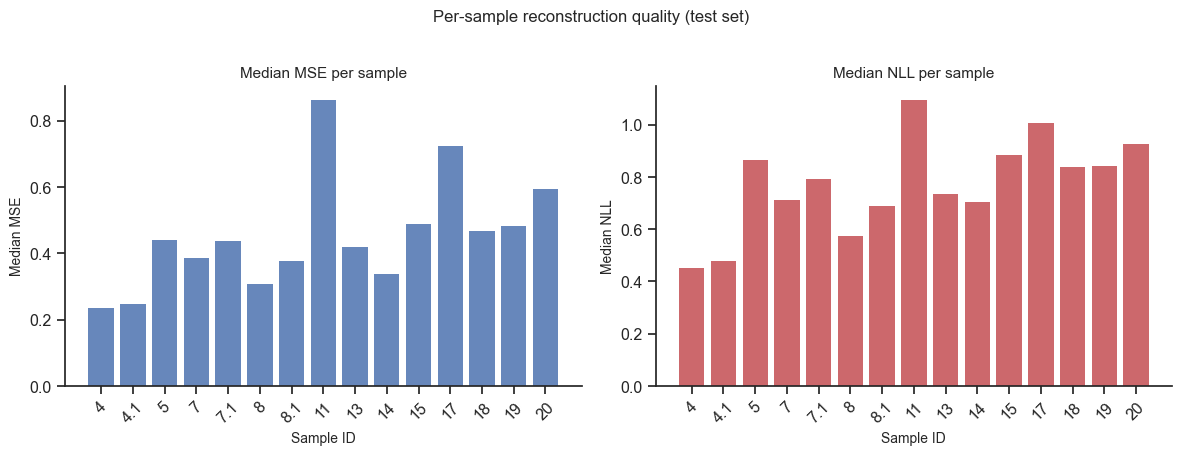

In [99]:
# ── Per-sample reconstruction MSE (test cells) ────────────────────────────────
test_recon_df = w_test[['cell_id']].merge(
    meta[['cell_id', 'sample_id']], on='cell_id', how='left'
).copy()
test_recon_df['mse'] = mse_per_cell
test_recon_df['nll'] = nll_per_cell

sample_recon = (
    test_recon_df.groupby('sample_id')[['mse', 'nll']]
    .median()
    .reindex(SAMPLES)
)

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
for ax, col, label, color in zip(
    axes, ['mse', 'nll'], ['Median MSE', 'Median NLL'],
    ['#4c72b0', '#c44e52']
):
    ax.bar(sample_recon.index, sample_recon[col], color=color, edgecolor='none', alpha=0.85)
    ax.set_xlabel('Sample ID', fontsize=10)
    ax.set_ylabel(label, fontsize=10)
    ax.set_title(f'{label} per sample', fontsize=11)
    ax.tick_params(axis='x', rotation=45)
    sns.despine(ax=ax)

plt.suptitle('Per-sample reconstruction quality (test set)', fontsize=12, y=1.01)
plt.tight_layout()
plt.savefig(OUT_DIR / 'reconstruction_per_sample.pdf', bbox_inches='tight')
plt.show()
sample_recon.to_csv(OUT_DIR / 'reconstruction_per_sample.csv')

---
## Summary of saved outputs

In [100]:
saved = sorted(OUT_DIR.glob('*'))
print(f'Outputs written to: {OUT_DIR}')
print(f'Total files: {len(saved)}')
for f in saved:
    print(f'  {f.name}')

Outputs written to: /Users/ronguy/Dropbox/Work/CyTOF/Experiments/ProbAE_Deconv/outputs/breast_pae_k05_analysis
Total files: 22
  archetype_means_clustermap.pdf
  archetype_means_heatmap.pdf
  archetype_top_markers.csv
  archetype_vars_heatmap.pdf
  dominant_archetype.pdf
  marker_archetype_pearson.csv
  marker_archetype_pearson.pdf
  marker_archetype_spearman.csv
  marker_archetype_spearman.pdf
  per_sample_mean_weights.csv
  per_sample_mean_weights_heatmap.pdf
  per_sample_stacked_bar.pdf
  reconstruction_per_marker_mse.csv
  reconstruction_per_marker_mse.pdf
  reconstruction_per_sample.csv
  reconstruction_per_sample.pdf
  reconstruction_quality_hist.pdf
  training_history.pdf
  umap_dominant_archetype.pdf
  umap_entropy.pdf
  umap_sample_id.pdf
  weight_entropy.pdf
